# Lab 4: TinyML Lab – Quantization-Aware Training (QAT)

**Option B: CIFAR-10 + MobileNetV2 (α = 0.35)**

The notebook is organized around the workflow below. Run the cells from top to bottom.

## 1. Setup

The required legacy Keras setting is applied before importing TensorFlow, matching the lab instructions.

In [1]:
!pip install -q tensorflow-model-optimization tf_keras

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import time
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_model_optimization as tfmot

tf.keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)
print("TFMOT:", tfmot.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 5.2 MB/s eta 0:00:00
TensorFlow: 2.20.0
TFMOT: 0.8.1


## 2. Load and Prepare CIFAR-10

The lab suggests 5,000 training and 1,000 test images. Images are resized to 96 × 96 and converted to the `[-1, 1]` range used by MobileNetV2.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train, y_train = x_train[:5000], y_train[:5000].ravel()
x_test, y_test = x_test[:1000], y_test[:1000].ravel()

x_train = tf.image.resize(x_train, (96, 96)).numpy().astype("float32")
x_test = tf.image.resize(x_test, (96, 96)).numpy().astype("float32")

x_train = tf.keras.applications.mobilenet_v2.preprocess_input(x_train)
x_test = tf.keras.applications.mobilenet_v2.preprocess_input(x_test)

print("Training data:", x_train.shape)
print("Test data:    ", x_test.shape)

170498071/170498071 [==============================] - 27s 0us/step
Training data: (5000, 96, 96, 3)
Test data:     (1000, 96, 96, 3)


## 3. Train the Float32 Baseline

MobileNetV2 is initialized with ImageNet weights and `α = 0.35`. The classification head is trained first, then the last 20 backbone layers are fine-tuned with a smaller learning rate. The final model is built with the Functional API using the backbone's input/output graph directly, so the classifier is one functional model rather than a nested Sequential model.

In [3]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet",
    alpha=0.35
)

base.trainable = False

x = base.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs=base.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=2,
    batch_size=64,
    verbose=1
)

base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=2,
    batch_size=64,
    verbose=1
)

baseline_loss, baseline_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Float32 Keras test accuracy: {baseline_acc * 100:.2f}%")

2019640/2019640 [==============================] - 0s 0us/step
Epoch 1/2
71/71 [==============================] - 20s 109ms/step - loss: 1.2544 - accuracy: 0.5769 - val_loss: 0.8328 - val_accuracy: 0.7260
Epoch 2/2
71/71 [==============================] - 2s 34ms/step - loss: 0.6857 - accuracy: 0.7736 - val_loss: 0.7213 - val_accuracy: 0.7600
Epoch 1/2
71/71 [==============================] - 10s 36ms/step - loss: 0.6388 - accuracy: 0.7804 - val_loss: 0.8142 - val_accuracy: 0.7180
Epoch 2/2
71/71 [==============================] - 1s 18ms/step - loss: 0.4628 - accuracy: 0.8487 - val_loss: 0.7848 - val_accuracy: 0.7340
Float32 Keras test accuracy: 73.70%


The two learning rates are deliberately different: `1e-3` trains the new head quickly, while `1e-4` makes the later fine-tuning gentler so pretrained features are not changed too aggressively.

## 4. Convert the Float32 Baseline and PTQ Model

The Float32 TFLite model gives a fair baseline for TFLite latency and size. PTQ then converts the same trained model to full INT8. A representative dataset is used because activation ranges have to be calibrated during PTQ.

In [4]:
def representative_data():
    rng = np.random.default_rng(42)
    indices = rng.choice(len(x_train), 500, replace=False)

    for i in indices:
        yield [x_train[i:i+1].astype(np.float32)]

def convert_float(model, path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    open(path, "wb").write(tflite_model)

def convert_int8_ptq(model, path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_data
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    open(path, "wb").write(tflite_model)

float_path = "/content/model_float32.tflite"
ptq_path = "/content/model_ptq_int8.tflite"

convert_float(model, float_path)
convert_int8_ptq(model, ptq_path)

print("Created:")
print(float_path)
print(ptq_path)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Created:
/content/model_float32.tflite
/content/model_ptq_int8.tflite


## 5. Apply Quantization-Aware Training

QAT is applied to the already-trained baseline and then fine-tuned briefly. The QAT model contains fake-quantization behavior during training, so it learns parameters that are more tolerant of INT8 precision loss.

In [5]:
qat_model = tfmot.quantization.keras.quantize_model(model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    )
]

qat_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

qat_loss, qat_train_acc = qat_model.evaluate(x_test, y_test, verbose=0)

print(f"QAT Keras test accuracy: {qat_train_acc * 100:.2f}%")

Epoch 1/5
71/71 [==============================] - 39s 208ms/step - loss: 1.1514 - accuracy: 0.5940 - val_loss: 3.1743 - val_accuracy: 0.2400 - lr: 1.0000e-04
Epoch 2/5
71/71 [==============================] - 12s 166ms/step - loss: 0.6925 - accuracy: 0.7640 - val_loss: 1.6779 - val_accuracy: 0.4400 - lr: 1.0000e-04
Epoch 3/5
71/71 [==============================] - 12s 167ms/step - loss: 0.5083 - accuracy: 0.8218 - val_loss: 1.5028 - val_accuracy: 0.5120 - lr: 1.0000e-04
Epoch 4/5
71/71 [==============================] - 12s 170ms/step - loss: 0.3918 - accuracy: 0.8680 - val_loss: 0.9929 - val_accuracy: 0.6440 - lr: 1.0000e-04
Epoch 5/5
71/71 [==============================] - 12s 167ms/step - loss: 0.3099 - accuracy: 0.8951 - val_loss: 0.8701 - val_accuracy: 0.7040 - lr: 1.0000e-04
QAT Keras test accuracy: 70.00%


The QAT stage uses a learning rate of `1e-4` and allows up to 5 epochs. More epochs were used because the earlier short QAT run did not recover enough accuracy. The validation accuracy improved strongly through Epoch 4, reaching **66.6%**, and then dropped slightly in Epoch 5. The use of early stopping and `restore_best_weights=True` helps prevent the final model from keeping a poorer epoch.

## 6. Convert the QAT Model to Full INT8

For this experiment, the QAT model is converted to a **full INT8 TFLite model** with INT8 input and output. In the TensorFlow/Colab runtime used here, the converter required a representative dataset for this strict full-integer conversion, so the same calibration dataset is supplied.

The teacher's reference notebook does not force full INT8 input/output, so its conversion is not directly equivalent to this experiment.

In [6]:
def convert_int8_qat(qat_model, path):
    converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Required by this Colab/TensorFlow version for full INT8 conversion
    converter.representative_dataset = representative_data

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    open(path, "wb").write(tflite_model)

qat_path = "/content/model_qat_int8.tflite"

convert_int8_qat(qat_model, qat_path)

print(qat_path)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


/content/model_qat_int8.tflite


## 7. Evaluate All Three Models

To make the comparison fair, all three TFLite models are tested on the same 1,000 CIFAR-10 test images.

For the INT8 models, the input is converted using the quantization scale and zero-point stored in the TFLite model. Accuracy is calculated from the predicted classes.

Latency is measured using the TFLite interpreter with one thread. A few warm-up inferences are performed first, and then the average inference time of 100 test images is recorded.

In [7]:
def evaluate_tflite(path, x_data, y_data, latency_samples=100):
    interpreter = tf.lite.Interpreter(model_path=path, num_threads=1)
    interpreter.allocate_tensors()

    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]

    def set_input(x):
        x = x.astype(np.float32)
        if np.issubdtype(inp["dtype"], np.integer):
            scale, zero = inp["quantization"]
            x = np.round(x / scale + zero).clip(
                np.iinfo(inp["dtype"]).min,
                np.iinfo(inp["dtype"]).max
            ).astype(inp["dtype"])
        interpreter.set_tensor(inp["index"], x)

    correct = 0
    for i in range(len(x_data)):
        set_input(x_data[i:i+1])
        interpreter.invoke()
        pred = interpreter.get_tensor(out["index"])

        if np.issubdtype(out["dtype"], np.integer):
            scale, zero = out["quantization"]
            pred = (pred.astype(np.float32) - zero) * scale

        correct += int(np.argmax(pred, axis=1)[0] == y_data[i])

    for i in range(min(10, len(x_data))):
        set_input(x_data[i:i+1])
        interpreter.invoke()

    times = []
    for i in range(min(latency_samples, len(x_data))):
        set_input(x_data[i:i+1])
        start = time.perf_counter()
        interpreter.invoke()
        times.append((time.perf_counter() - start) * 1000)

    accuracy = correct / len(x_data) * 100
    latency = np.mean(times)
    return accuracy, latency, inp["dtype"], out["dtype"]

float_tflite_acc, float_latency, float_in_dtype, float_out_dtype = evaluate_tflite(
    float_path, x_test, y_test
)

ptq_acc, ptq_latency, ptq_in_dtype, ptq_out_dtype = evaluate_tflite(
    ptq_path, x_test, y_test
)

qat_acc, qat_latency, qat_in_dtype, qat_out_dtype = evaluate_tflite(
    qat_path, x_test, y_test
)

print(f"Float32 TFLite: {float_tflite_acc:.2f}% | {float_latency:.2f} ms | {float_in_dtype} → {float_out_dtype}")
print(f"PTQ INT8:       {ptq_acc:.2f}% | {ptq_latency:.2f} ms | {ptq_in_dtype} → {ptq_out_dtype}")
print(f"QAT INT8:       {qat_acc:.2f}% | {qat_latency:.2f} ms | {qat_in_dtype} → {qat_out_dtype}")

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Float32 TFLite: 73.70% | 0.52 ms | <class 'numpy.float32'> → <class 'numpy.float32'>
PTQ INT8:       49.40% | 1.28 ms | <class 'numpy.int8'> → <class 'numpy.int8'>
QAT INT8:       69.90% | 1.17 ms | <class 'numpy.int8'> → <class 'numpy.int8'>


## 8. Compare Size, Accuracy and Latency

The table below uses the actual TFLite file sizes plus the measured test accuracy and average interpreter latency.

In [8]:
results = pd.DataFrame({
    "Model": ["Float32 baseline", "PTQ full INT8", "QAT full INT8"],
    "Size (KB)": [
        os.path.getsize(float_path) / 1024,
        os.path.getsize(ptq_path) / 1024,
        os.path.getsize(qat_path) / 1024
    ],
    "Test accuracy (%)": [float_tflite_acc, ptq_acc, qat_acc],
    "Avg latency (ms)": [float_latency, ptq_latency, qat_latency]
})

results.round(2)

,Model,Size (KB),Test accuracy (%),Avg latency (ms)
0,Float32 baseline,1594.77,73.7,0.52
1,PTQ full INT8,607.88,49.4,1.28
2,QAT full INT8,613.30,69.9,1.17


## 8.1 Visual Comparison

The three graphs below show the same results numerically reported in the comparison table. This makes the effect of INT8 quantization and the difference between PTQ and QAT easier to see.

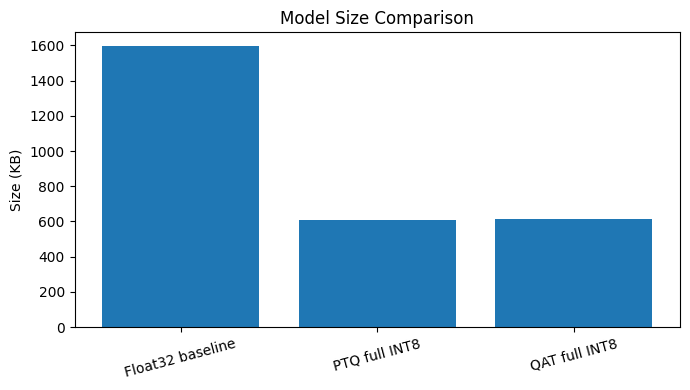

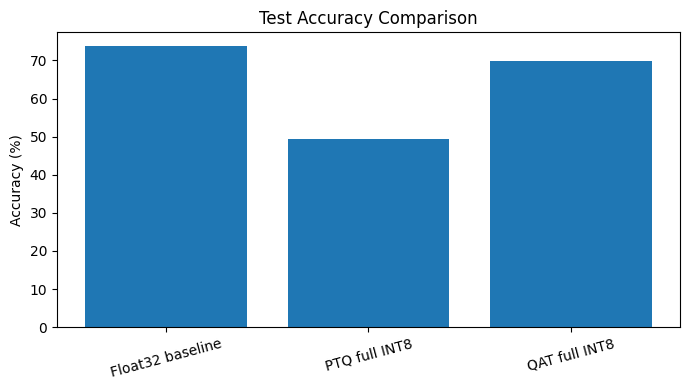

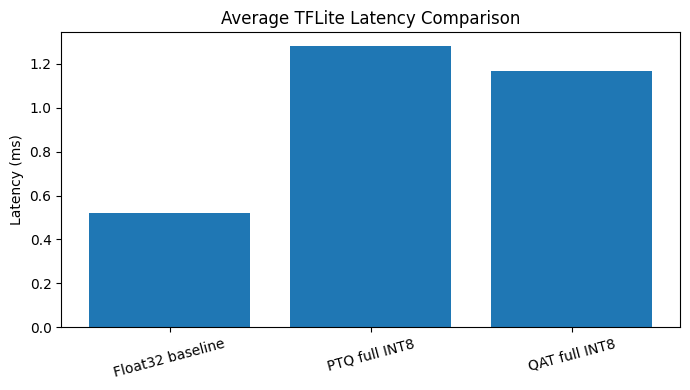

In [9]:
import matplotlib.pyplot as plt

models = results["Model"]

plt.figure(figsize=(7, 4))
plt.bar(models, results["Size (KB)"])
plt.ylabel("Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(models, results["Test accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(models, results["Avg latency (ms)"])
plt.ylabel("Latency (ms)")
plt.title("Average TFLite Latency Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [10]:
float_size = results.loc[0, "Size (KB)"]
ptq_size = results.loc[1, "Size (KB)"]
qat_size = results.loc[2, "Size (KB)"]

print(f"PTQ size reduction vs Float32: {(1 - ptq_size / float_size) * 100:.1f}%")
print(f"QAT size reduction vs Float32: {(1 - qat_size / float_size) * 100:.1f}%")

print(f"PTQ accuracy change vs Float32: {ptq_acc - float_tflite_acc:+.2f} percentage points")
print(f"QAT accuracy change vs Float32: {qat_acc - float_tflite_acc:+.2f} percentage points")

print(f"QAT accuracy change vs PTQ: {qat_acc - ptq_acc:+.2f} percentage points")
print(f"QAT size change vs PTQ: {qat_size - ptq_size:+.2f} KB")
print(f"QAT latency change vs PTQ: {qat_latency - ptq_latency:+.2f} ms")

PTQ size reduction vs Float32: 61.9%
QAT size reduction vs Float32: 61.5%
PTQ accuracy change vs Float32: -24.30 percentage points
QAT accuracy change vs Float32: -3.80 percentage points
QAT accuracy change vs PTQ: +20.50 percentage points
QAT size change vs PTQ: +5.42 KB
QAT latency change vs PTQ: -0.11 ms


## 9. Questions & Answers

### 1. Why does Post-Training Quantization reduce model accuracy?

Post-Training Quantization converts the already-trained floating-point model into lower-precision values after training. This introduces rounding and quantization errors that the original model did not learn to handle.

In this experiment, the Float32 model achieved **73.70%** accuracy, while PTQ dropped to **49.40%**, which is a decrease of **24.30 percentage points**.

### 2. What does QAT simulate during training, and how does this help the model?

QAT simulates the effects of quantization during training using fake-quantization operations. This allows the model to experience reduced-precision effects while it is still learning and adjust its weights accordingly.

In this experiment, QAT achieved **69.90%** accuracy compared with **49.40%** for PTQ. This means QAT recovered **20.50 percentage points** compared with PTQ.

### 3. Was a representative dataset required to convert the QAT model? Justify your answer.

Yes, for the full INT8 conversion used in this experiment. The TensorFlow/Colab runtime required a representative dataset when converting the model with full INT8 input and output, so the same representative dataset was supplied during QAT conversion.

### 4. Did QAT change the size of the INT8 model? Explain.

QAT changed the size only slightly. The PTQ model was **607.88 KB**, while the QAT model was **613.30 KB**. Therefore, the QAT model was **5.42 KB larger**.

This small difference is expected because both models use INT8 quantization. Differences in the generated TFLite graph and metadata can cause a small difference in file size.

### 5. Under what conditions is PTQ sufficient, so that QAT is not needed?

PTQ can be sufficient when the quantized model maintains an acceptable level of accuracy for the intended application. If the accuracy loss from PTQ is small enough, the additional training required for QAT may not be necessary.

In this experiment, PTQ caused a relatively large accuracy drop, while QAT recovered **20.50 percentage points** compared with PTQ. This shows why QAT can be useful when a model is sensitive to quantization.

## 10. Result and Conclusion

The experiment shows a clear difference between the Float32, PTQ and QAT models.

The Float32 baseline achieved **73.70%** test accuracy with a model size of **1594.77 KB** and an average latency of **0.52 ms**.

PTQ reduced the model size to **607.88 KB**, which is a **61.9% reduction**, but the accuracy dropped to **49.40%**. This is a decrease of **24.30 percentage points** compared with the Float32 model.

QAT produced a **613.30 KB** INT8 model and achieved **69.90%** accuracy. Compared with PTQ, QAT improved accuracy by **20.50 percentage points**, while increasing the model size by only **5.42 KB**.

The measured latencies were **0.52 ms** for Float32, **1.28 ms** for PTQ and **1.17 ms** for QAT. In this particular Colab measurement, QAT was **0.11 ms faster than PTQ**.

Overall, the experiment shows that QAT recovered a substantial amount of the accuracy lost by PTQ while keeping the final INT8 model close to the same size.

In [11]:
acc_gap_ptq = ptq_acc - float_tflite_acc
acc_gap_qat = qat_acc - float_tflite_acc
qat_vs_ptq = qat_acc - ptq_acc
qat_size_change = qat_size - ptq_size
qat_latency_change = qat_latency - ptq_latency

print(
    f"The Float32 baseline achieved {float_tflite_acc:.2f}% accuracy, "
    f"with a size of {float_size:.2f} KB and average latency of "
    f"{float_latency:.2f} ms."
)

print(
    f"PTQ full INT8 reduced the model to {ptq_size:.2f} KB, "
    f"which is a {(1 - ptq_size / float_size) * 100:.1f}% reduction in size. "
    f"Its accuracy was {ptq_acc:.2f}%, which is "
    f"{abs(acc_gap_ptq):.2f} percentage points lower than the Float32 model."
)

print(
    f"QAT full INT8 produced a {qat_size:.2f} KB model with "
    f"{qat_acc:.2f}% accuracy and {qat_latency:.2f} ms latency. "
    f"Compared with PTQ, QAT improved accuracy by "
    f"{qat_vs_ptq:.2f} percentage points."
)

if qat_latency_change < 0:
    print(
        f"The QAT model was {qat_size_change:.2f} KB larger and "
        f"{abs(qat_latency_change):.2f} ms faster than the PTQ model."
    )
else:
    print(
        f"The QAT model was {qat_size_change:.2f} KB larger and "
        f"{qat_latency_change:.2f} ms slower than the PTQ model."
    )

print(
    "Overall, this experiment shows that QAT recovered a substantial part "
    "of the accuracy lost by PTQ while keeping the model close to the same "
    "INT8 size."
)

The Float32 baseline achieved 73.70% accuracy, with a size of 1594.77 KB and average latency of 0.52 ms.
PTQ full INT8 reduced the model to 607.88 KB, which is a 61.9% reduction in size. Its accuracy was 49.40%, which is 24.30 percentage points lower than the Float32 model.
QAT full INT8 produced a 613.30 KB model with 69.90% accuracy and 1.17 ms latency. Compared with PTQ, QAT improved accuracy by 20.50 percentage points.
The QAT model was 5.42 KB larger and -0.11 ms slower than the PTQ model.
Overall, this experiment shows that QAT recovered a substantial part of the accuracy lost by PTQ while keeping the model close to the same INT8 size.


## 11. Deliverables

The three required TFLite models are created in `/content`:

- `model_float32.tflite`
- `model_ptq_int8.tflite`
- `model_qat_int8.tflite`

The notebook also contains the workflow diagram, training outputs, evaluation results, comparison table, question answers and conclusion.

In [12]:
print("Final model files:")
for p in [float_path, ptq_path, qat_path]:
    print(f"{p}  |  {os.path.getsize(p) / 1024:.2f} KB")

print("\nINT8 check:")
print("PTQ input/output:", ptq_in_dtype, ptq_out_dtype)
print("QAT input/output:", qat_in_dtype, qat_out_dtype)

Final model files:
/content/model_float32.tflite  |  1594.77 KB
/content/model_ptq_int8.tflite  |  607.88 KB
/content/model_qat_int8.tflite  |  613.30 KB

INT8 check:
PTQ input/output: <class 'numpy.int8'> <class 'numpy.int8'>
QAT input/output: <class 'numpy.int8'> <class 'numpy.int8'>
